In [1]:
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

import matplotlib.pyplot as plt 

In [2]:
raw_data = "../data/deltas_vs_rmsd.csv"
data = np.loadtxt(raw_data, delimiter=',', skiprows=1)
data = data[1:-1:100]
X = data[:, :3]
y = data[:, 3:]
data.shape

(4995, 4)

In [10]:
raw_data = "../data/vtors_vs_rmsd.csv"

data = np.loadtxt(raw_data, delimiter=',', skiprows=1)
data = data[1:-1:10]
X = data[:, :6]
y = data[:, 6:]

y

array([[2.04375529],
       [0.13739526],
       [0.14613594],
       ...,
       [3.87416697],
       [2.7538209 ],
       [4.82176447]])

In [4]:
# Normalize features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled, dtype=torch.float32)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=0.2, random_state=42)


Epoch 50/500, Loss: 0.2732
Epoch 100/500, Loss: 0.0641
Epoch 150/500, Loss: 0.0379
Epoch 200/500, Loss: 0.0290
Epoch 250/500, Loss: 0.0269
Epoch 300/500, Loss: 0.0296
Epoch 350/500, Loss: 0.0249
Epoch 400/500, Loss: 0.0223
Epoch 450/500, Loss: 0.0219
Epoch 500/500, Loss: 0.0211


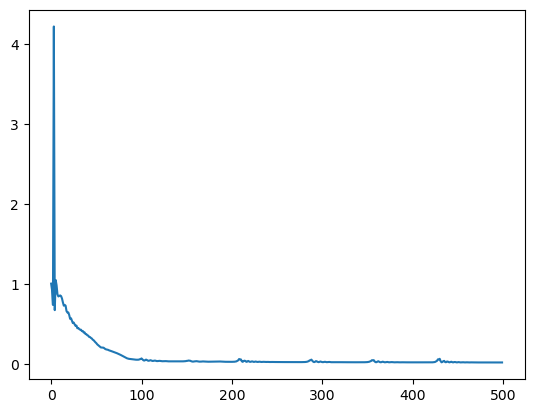

In [5]:
model = nn.Sequential(
            nn.Linear(6, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.1)


epochs = 500
ldat = []
for epoch in range(epochs):
    pred = model(X_train)
    loss = loss_fn(pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    ldat.append(loss.item())
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")
plt.plot(ldat)

RMSE  0.043944567
PearsonRResult(statistic=0.9891083070968603, pvalue=0.0)


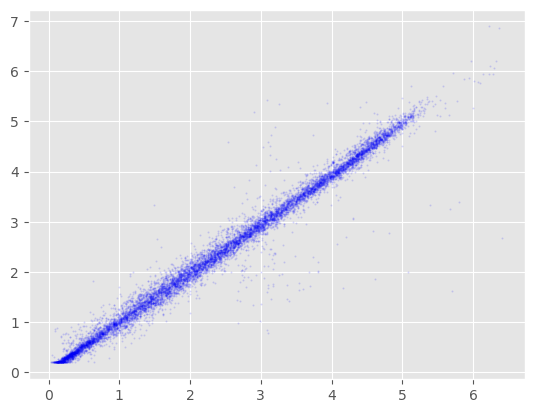

In [6]:
# Test the model
model.eval()
with torch.no_grad():
    test_preds = model(X_test)
    test_preds_rescaled = scaler_y.inverse_transform(test_preds.numpy())
    y_test_rescaled = scaler_y.inverse_transform(y_test.numpy())

plt.style.use('ggplot')
plt.scatter(y_test_rescaled, test_preds_rescaled, marker='o', s=1, color='blue', alpha=0.1)
print("RMSE ", mean_squared_error(y_test_rescaled[:,0], test_preds_rescaled[:,0]))
print(pearsonr(y_test_rescaled[:,0], test_preds_rescaled[:,0]))